# 少数派博弈
## The Minority Game

**从爱尔法鲁到少数派博弈**

1997 年，Challet 和 Zhang 把爱尔法鲁问题精炼成一个更简洁的形式：

> N 个 agent（奇数），每轮各自选择 0 或 1。  
> 选择了**少数一边**的人获胜。

这个抽象去掉了「酒吧」这个具体场景，保留了核心矛盾：
- 理性地追求多数人的选择会让你输
- 每个人的最优策略取决于其他所有人的策略
- 没有中央协调，只有局部信息

少数派博弈最令人震惊的发现是：系统存在一个临界点 **αc ≈ 0.34**，在这个点附近，集体协调能力达到峰值——这是一种典型的相变现象，类似物理学中的铁磁相变。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from itertools import product

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 策略空间的结构

**历史字符串（History String）**

每轮结束后，系统记录「少数派是哪一边（0 或 1）」。  
过去 m 轮的记录构成一个长度为 m 的二进制字符串，例如 m=3 时：`101`。

m=3 时，一共有 2³ = 8 种可能的历史模式。

**策略是一张查找表**

一个策略就是对所有 2ᵐ 种历史模式各指定一个行动（0 或 1）。  
m=3 时，策略空间共有 2^(2³) = 2⁸ = **256 种**不同策略。

每个 agent 在游戏开始前随机抽取 s 个策略，并在整个游戏过程中只使用这些策略。

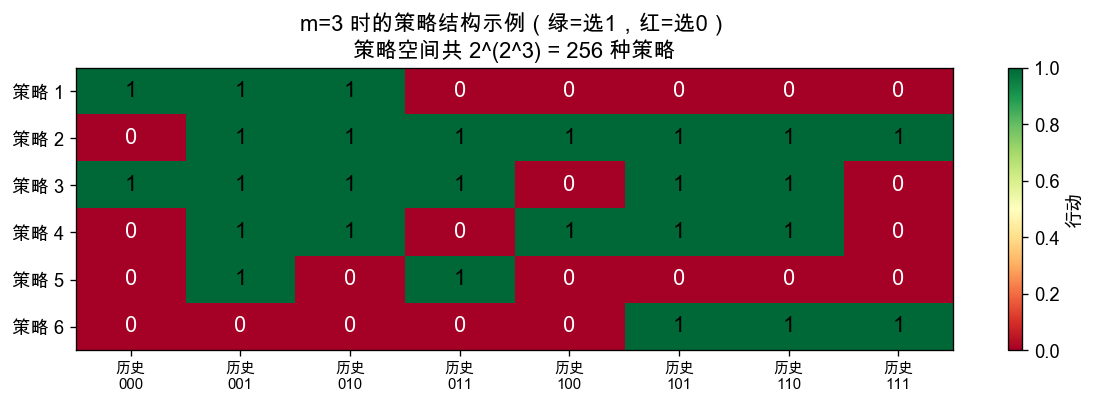

m=3: 历史模式数 P = 8,  策略空间大小 = 256


In [2]:
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

def visualize_strategy_space(m=3):
    P = 2**m
    total_strategies = 2**P

    # 展示所有历史模式
    history_patterns = [format(i, f'0{m}b') for i in range(P)]

    # 随机抽取 6 个策略展示
    rng = np.random.default_rng(0)
    sample_strategies = rng.integers(0, 2, size=(6, P))

    fig, ax = plt.subplots(figsize=(10, 3.5))
    im = ax.imshow(sample_strategies, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

    ax.set_xticks(range(P))
    ax.set_xticklabels([f'历史\n{p}' for p in history_patterns], fontsize=9)
    ax.set_yticks(range(6))
    ax.set_yticklabels([f'策略 {i+1}' for i in range(6)])

    for i in range(6):
        for j in range(P):
            val = sample_strategies[i, j]
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if val == 0 else 'black')

    ax.set_title(f'm={m} 时的策略结构示例（绿=选1，红=选0）\n'
                 f'策略空间共 2^(2^{m}) = {total_strategies} 种策略', fontweight='bold')
    plt.colorbar(im, ax=ax, label='行动')
    plt.tight_layout()
    plt.show()

    print(f'm={m}: 历史模式数 P = {P},  策略空间大小 = {total_strategies}')

visualize_strategy_space(m=3)

## 核心模型实现

In [3]:
class MinorityGame:
    """
    标准少数派博弈模型。

    N: agent 数量（奇数）
    m: 记忆长度（历史窗口）
    s: 每个 agent 持有的策略数
    """

    def __init__(self, N: int, m: int, s: int = 2, seed: int = 42):
        assert N % 2 == 1, "N 必须是奇数"
        self.N = N
        self.m = m
        self.s = s
        self.P = 2**m

        rng = np.random.default_rng(seed)

        # 每个 agent 的 s 个策略：shape (N, s, P)，取值为 0 或 1
        self.strategies = rng.integers(0, 2, size=(N, s, self.P))

        # 每个策略的累积得分
        self.scores = np.zeros((N, s), dtype=float)

        # 随机初始化历史（用整数列表表示，0 或 1）
        self.history = list(rng.integers(0, 2, size=m))

        self.attendance_log = []   # 每轮选择 1 的人数
        self.minority_log  = []    # 每轮少数派行动

    def _history_index(self) -> int:
        """将最近 m 轮的历史转换为整数索引"""
        idx = 0
        for bit in self.history[-self.m:]:
            idx = (idx << 1) | int(bit)
        return idx

    def step(self) -> int:
        hist_idx = self._history_index()

        # 每个 agent 使用当前得分最高的策略
        best = np.argmax(self.scores, axis=1)          # (N,)
        actions = self.strategies[np.arange(self.N), best, hist_idx]  # (N,)

        attendance = int(actions.sum())
        # 选 1 的人数 > N/2 → 1 是多数方 → 少数方是 0，反之亦然
        minority_action = 0 if attendance > self.N // 2 else 1

        # 虚拟评估：对所有策略打分
        # 预测了少数方行动的策略 +1，否则 -1（或不变，视实现而定）
        predicted = self.strategies[:, :, hist_idx]    # (N, s)
        self.scores += np.where(predicted == minority_action, 1, -1)

        # 历史只记录「少数方是哪边」
        self.history.append(minority_action)
        self.attendance_log.append(attendance)
        self.minority_log.append(minority_action)
        return attendance

    def run(self, T: int) -> np.ndarray:
        for _ in range(T):
            self.step()
        return np.array(self.attendance_log)

    @property
    def sigma2(self) -> float:
        """出勤方差 σ² / N（归一化，用于比较不同规模的系统）"""
        A = np.array(self.attendance_log)
        return A.var() / self.N

## 基础模拟：观察系统行为

σ²/N = 1.4967   （随机决策基准：σ²/N ≈ 0.25）


/var/folders/z7/cyhjg5j93vs6sgm3ql7yhz9h0000gn/T/ipykernel_13846/3638411550.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


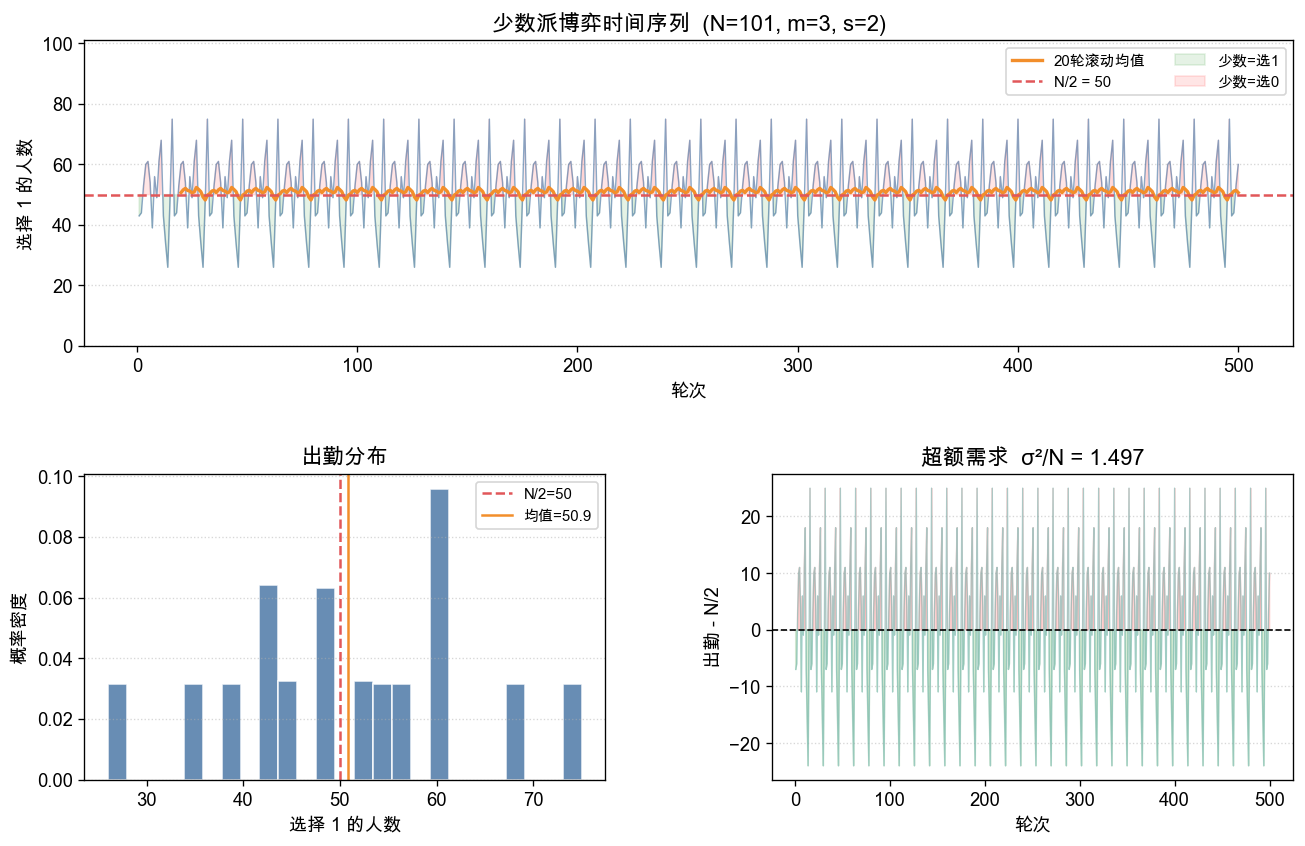

In [4]:
N, m, T = 101, 3, 500
mg = MinorityGame(N=N, m=m, s=2, seed=42)
attendance = mg.run(T)

fig = plt.figure(figsize=(13, 8))
gs = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

weeks = np.arange(1, T+1)

# --- 图1：出勤时间序列 ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(weeks, attendance, color='#4e79a7', alpha=0.65, linewidth=0.85)
window = 20
rm = np.convolve(attendance, np.ones(window)/window, mode='valid')
ax1.plot(weeks[window-1:], rm, color='#f28e2b', linewidth=2, label=f'{window}轮滚动均值')
ax1.axhline(N // 2, color='#e15759', linewidth=1.5, linestyle='--', label=f'N/2 = {N//2}')
ax1.fill_between(weeks, attendance, N//2,
                 where=(attendance <= N//2), alpha=0.1, color='green', label='少数=选1')
ax1.fill_between(weeks, attendance, N//2,
                 where=(attendance > N//2),  alpha=0.1, color='red',   label='少数=选0')
ax1.set_title(f'少数派博弈时间序列  (N={N}, m={m}, s=2)', fontweight='bold')
ax1.set_ylabel('选择 1 的人数')
ax1.set_xlabel('轮次')
ax1.set_ylim(0, N)
ax1.legend(fontsize=9, ncol=2)
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# --- 图2：分布 ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(attendance, bins=25, color='#4e79a7', edgecolor='white', alpha=0.85, density=True)
ax2.axvline(N//2, color='#e15759', linewidth=1.5, linestyle='--', label=f'N/2={N//2}')
ax2.axvline(attendance.mean(), color='#f28e2b', linewidth=1.5,
            label=f'均值={attendance.mean():.1f}')
ax2.set_title('出勤分布')
ax2.set_xlabel('选择 1 的人数')
ax2.set_ylabel('概率密度')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

# --- 图3：超额回报（Excess demand）---
ax3 = fig.add_subplot(gs[1, 1])
excess = attendance - N // 2   # 正 = 多数选了1（选0的人赢），负 = 反之
ax3.plot(weeks, excess, color='#76b7b2', alpha=0.6, linewidth=0.8)
ax3.axhline(0, color='black', linewidth=1, linestyle='--')
ax3.fill_between(weeks, excess, 0, where=(excess > 0), alpha=0.15, color='red')
ax3.fill_between(weeks, excess, 0, where=(excess < 0), alpha=0.15, color='green')
ax3.set_title(f'超额需求  σ²/N = {mg.sigma2:.3f}')
ax3.set_xlabel('轮次')
ax3.set_ylabel('出勤 - N/2')
ax3.grid(axis='y', linestyle=':', alpha=0.5)

print(f'σ²/N = {mg.sigma2:.4f}   （随机决策基准：σ²/N ≈ {0.25:.2f}）')
plt.tight_layout()
plt.show()

## 核心发现：相变（Phase Transition）

少数派博弈最重要的理论结果是关于参数 **α = 2ᵐ / N**（又称「复杂度比」）：

- **α 小**（m 小、N 大）：策略池相对于 agent 数量太小。许多 agent 会抽到相同或高度相关的策略，形成「羊群效应」，集体协调能力差，σ²/N 很高
- **α 大**（m 大、N 小）：策略足够多样，但 agent 数量不足以填满市场的双方，系统退化为接近随机行为，σ²/N → 0.25（掷硬币基准）
- **α ≈ αc ≈ 0.34**：存在一个临界点，在这里集体协调能力最强（σ²/N 最小）

我们来验证这个相变：

In [5]:
# 扫描 α = 2^m / N
# 固定 N，改变 m
N_fixed = 201
m_values = range(1, 9)       # m = 1..8
T_sim = 2000                  # 每次模拟轮数
n_seeds = 8                   # 每组参数重复多次取均值，降低随机性

results = []   # (alpha, sigma2_mean, sigma2_std)

for m in m_values:
    alpha = (2**m) / N_fixed
    sigma2_list = []
    for seed in range(n_seeds):
        mg = MinorityGame(N=N_fixed, m=m, s=2, seed=seed)
        mg.run(T_sim)
        # 只取后半段数据，让系统有充分的预热时间
        A = np.array(mg.attendance_log[T_sim//2:])
        sigma2_list.append(A.var() / N_fixed)
    results.append((alpha, np.mean(sigma2_list), np.std(sigma2_list)))
    print(f'  m={m}, α={alpha:.3f}, σ²/N={np.mean(sigma2_list):.4f} ± {np.std(sigma2_list):.4f}')

results = np.array(results)

  m=1, α=0.010, σ²/N=2.9789 ± 0.7857
  m=2, α=0.020, σ²/N=2.7257 ± 0.7334
  m=3, α=0.040, σ²/N=1.9961 ± 0.6889
  m=4, α=0.080, σ²/N=1.0259 ± 0.2267
  m=5, α=0.159, σ²/N=0.4166 ± 0.0901
  m=6, α=0.318, σ²/N=0.1117 ± 0.0315
  m=7, α=0.637, σ²/N=0.0859 ± 0.0091
  m=8, α=1.274, σ²/N=0.1270 ± 0.0053


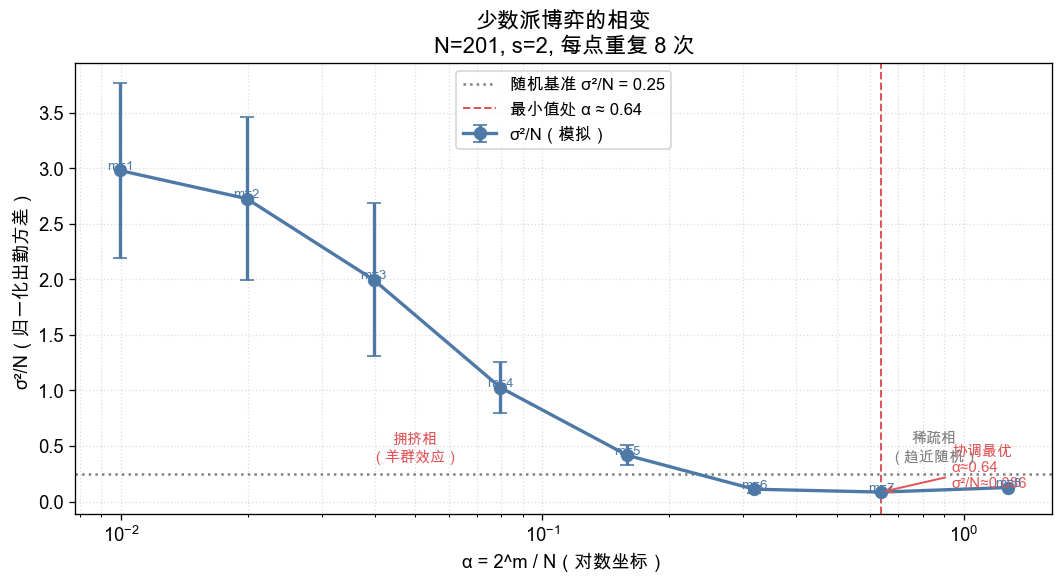

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

alphas     = results[:, 0]
sigma2_mean = results[:, 1]
sigma2_std  = results[:, 2]

ax.errorbar(alphas, sigma2_mean, yerr=sigma2_std,
            fmt='o-', color='#4e79a7', linewidth=2, markersize=7,
            capsize=4, label='σ²/N（模拟）')

# 随机基准：如果所有 agent 随机选择 0 或 1，σ²/N ≈ N*(0.5)*(0.5)/N = 0.25
ax.axhline(0.25, color='gray', linestyle=':', linewidth=1.5, label='随机基准 σ²/N = 0.25')

# 标注临界点附近的最小值
min_idx = np.argmin(sigma2_mean)
ax.axvline(alphas[min_idx], color='#e15759', linestyle='--', linewidth=1.2,
           label=f'最小值处 α ≈ {alphas[min_idx]:.2f}')
ax.annotate(f'协调最优\nα≈{alphas[min_idx]:.2f}\nσ²/N≈{sigma2_mean[min_idx]:.3f}',
            xy=(alphas[min_idx], sigma2_mean[min_idx]),
            xytext=(alphas[min_idx]+0.3, sigma2_mean[min_idx]+0.04),
            fontsize=9, color='#e15759',
            arrowprops=dict(arrowstyle='->', color='#e15759', lw=1.2))

# 标注 m 值
for i, (a, s, m) in enumerate(zip(alphas, sigma2_mean, m_values)):
    ax.text(a, s + 0.006, f'm={m}', ha='center', fontsize=8, color='#4e79a7')

ax.set_xscale('log')
ax.set_xlabel('α = 2^m / N（对数坐标）')
ax.set_ylabel('σ²/N（归一化出勤方差）')
ax.set_title(f'少数派博弈的相变\nN={N_fixed}, s=2, 每点重复 {n_seeds} 次', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle=':', alpha=0.4)

# 标注两个相区
ax.text(0.05, 0.18, '拥挤相\n（羊群效应）', ha='center', fontsize=9,
        color='#e15759', transform=ax.get_xaxis_transform(),
        verticalalignment='top')
ax.text(0.85, 0.18, '稀疏相\n（趋近随机）', ha='center', fontsize=9,
        color='gray', transform=ax.get_xaxis_transform(),
        verticalalignment='top')

plt.tight_layout()
plt.show()

## 深入相变：两个相的行为差异

让我们直观地看看「拥挤相」和「稀疏相」的出勤时间序列有何不同：

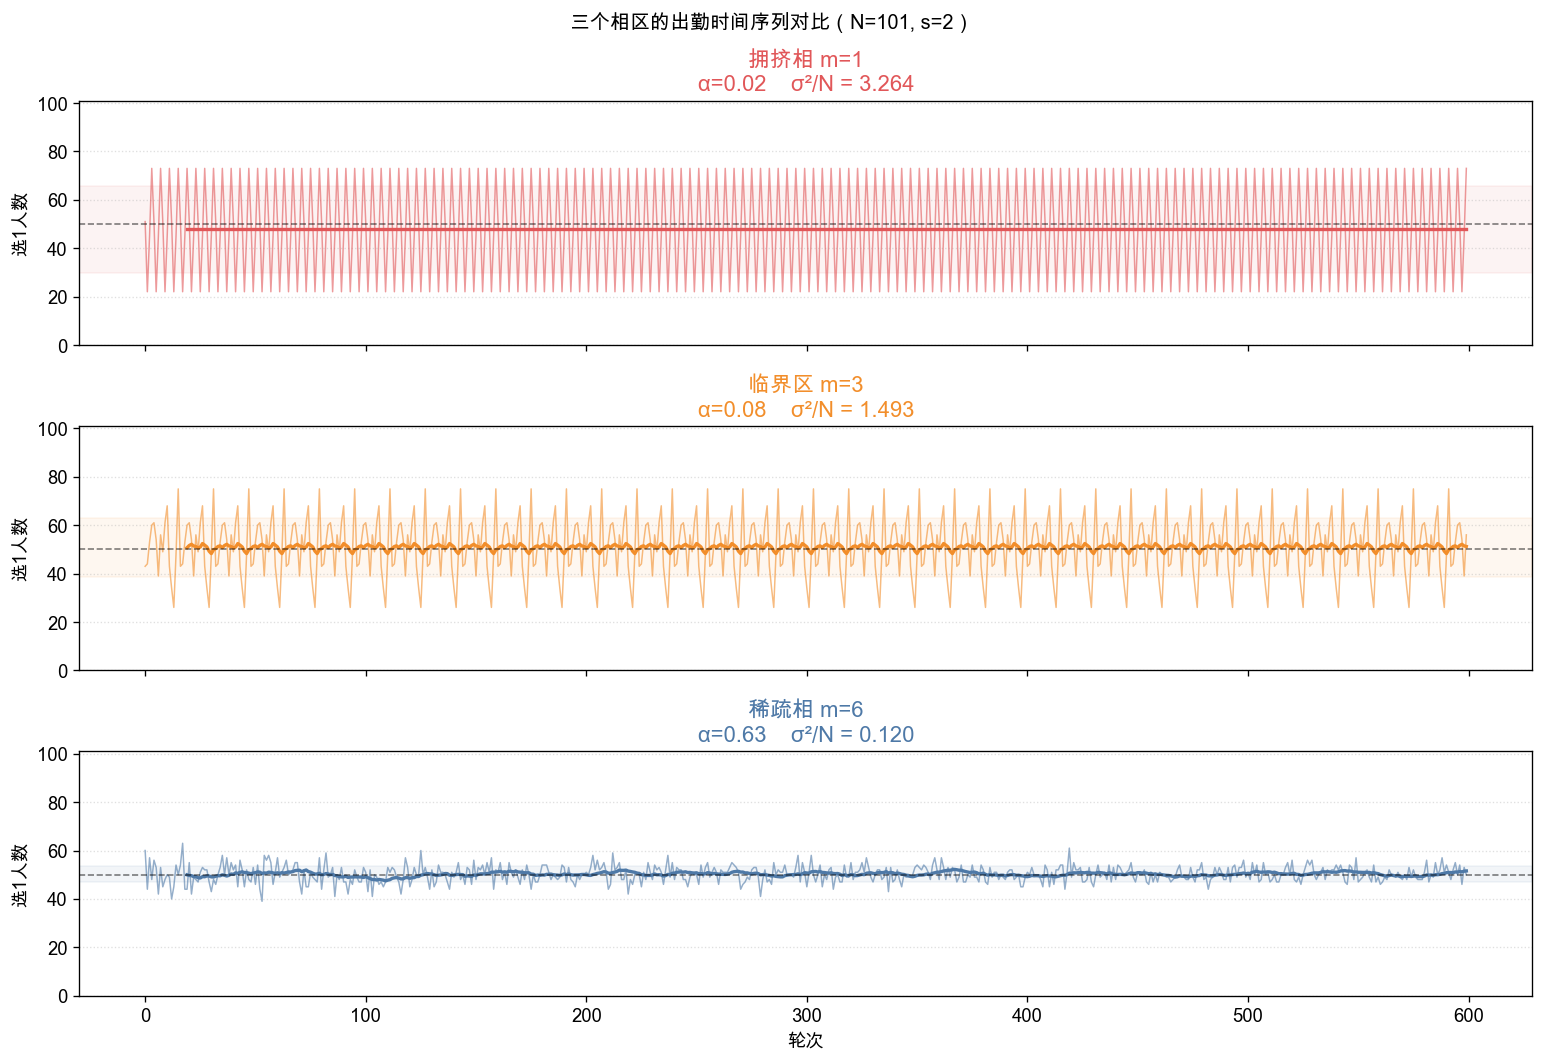

In [7]:
N = 101
T = 600
configs = [
    (1, '#e15759', f'拥挤相 m=1\nα={2**1/N:.2f}'),
    (3, '#f28e2b', f'临界区 m=3\nα={2**3/N:.2f}'),
    (6, '#4e79a7', f'稀疏相 m=6\nα={2**6/N:.2f}'),
]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for ax, (m, color, label) in zip(axes, configs):
    mg = MinorityGame(N=N, m=m, s=2, seed=42)
    att = mg.run(T)
    sigma2 = np.array(mg.attendance_log).var() / N

    ax.plot(att, color=color, alpha=0.6, linewidth=0.9)
    window = 20
    rm = np.convolve(att, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, T), rm, color=color, linewidth=2)
    ax.axhline(N//2, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_ylim(0, N)
    ax.set_ylabel('选1人数')
    ax.set_title(f'{label}    σ²/N = {sigma2:.3f}', fontweight='bold', color=color)
    ax.grid(axis='y', linestyle=':', alpha=0.4)

    # 标注方差范围
    mean_val = att.mean()
    std_val = att.std()
    ax.axhspan(mean_val - std_val, mean_val + std_val,
               alpha=0.07, color=color, label=f'±1σ 范围')

axes[-1].set_xlabel('轮次')
fig.suptitle('三个相区的出勤时间序列对比（N=101, s=2）', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 策略多样性与协调效率

为什么拥挤相（小 α）会有羊群效应？

当 m 小时，策略空间（2^(2^m) 种策略）相对于 agent 数量很小，不同 agent 会持有**反相关**的策略对——如果一个策略让你选 1，其「镜像策略」让你选 0。大量 agent 随机分布在这些策略上，但当某类策略开始失败，所有持有它的 agent 会**同时切换**，造成大幅摆动。

下面我们观察：系统中有多少 agent 在某一轮做出了「赢家」（少数派）的选择？

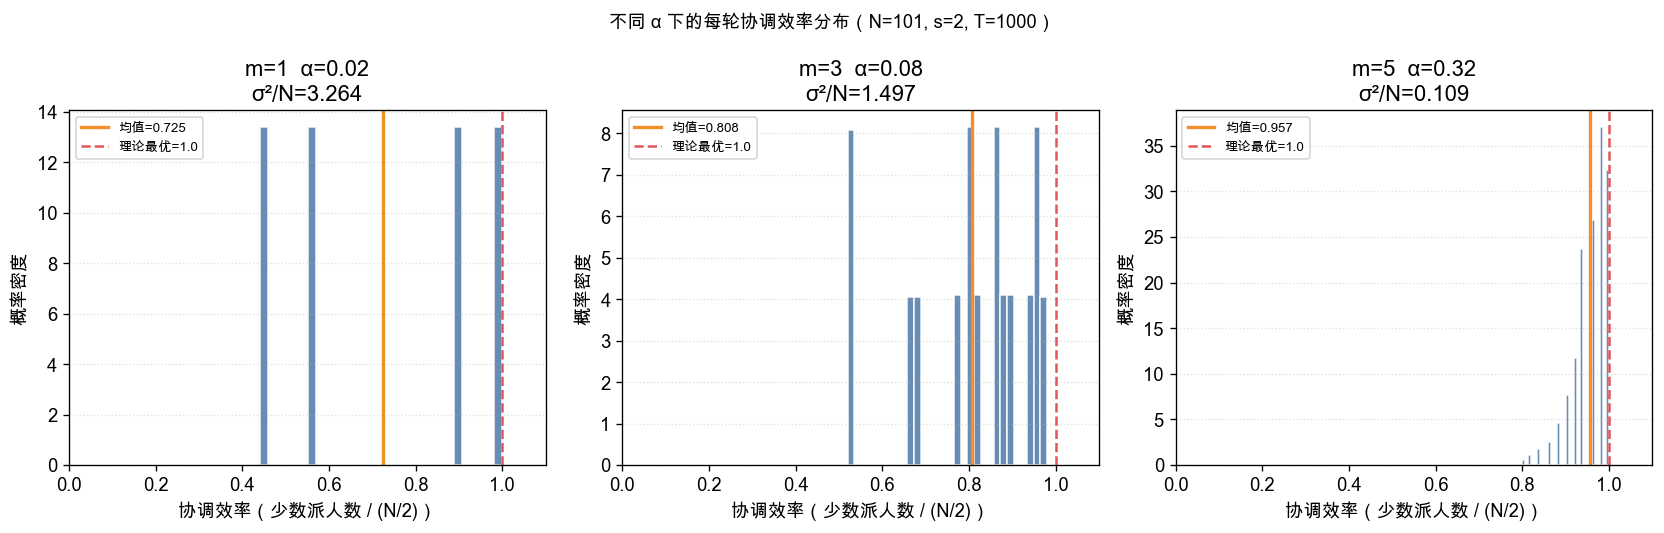

In [8]:
N = 101
T = 1000
m_list = [1, 3, 5]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, m in zip(axes, m_list):
    mg = MinorityGame(N=N, m=m, s=2, seed=42)
    att = mg.run(T)

    # 每轮「赢家」数量 = 少数派人数
    winners = np.minimum(att, N - att)
    efficiency = winners / (N // 2)  # 相对于最优的协调效率

    ax.hist(efficiency, bins=30, color='#4e79a7', edgecolor='white', alpha=0.85, density=True)
    ax.axvline(efficiency.mean(), color='#f28e2b', linewidth=2,
               label=f'均值={efficiency.mean():.3f}')
    ax.axvline(1.0, color='#e15759', linewidth=1.5, linestyle='--', label='理论最优=1.0')

    alpha = 2**m / N
    sigma2 = np.array(mg.attendance_log).var() / N
    ax.set_title(f'm={m}  α={alpha:.2f}\nσ²/N={sigma2:.3f}', fontweight='bold')
    ax.set_xlabel('协调效率（少数派人数 / (N/2)）')
    ax.set_ylabel('概率密度')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1.1)
    ax.grid(axis='y', linestyle=':', alpha=0.4)

fig.suptitle('不同 α 下的每轮协调效率分布（N=101, s=2, T=1000）',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 系统规模的影响（有限尺寸效应）

理论预测在 N → ∞ 时更准确。我们来看看不同 N 下相变曲线的变化：

In [9]:
N_list = [51, 101, 201, 501]
m_values = range(1, 8)
T_sim = 1500
n_seeds = 5

all_results = {}
for N in N_list:
    res = []
    for m in m_values:
        alpha = (2**m) / N
        sigma2_list = []
        for seed in range(n_seeds):
            mg = MinorityGame(N=N, m=m, s=2, seed=seed)
            mg.run(T_sim)
            A = np.array(mg.attendance_log[T_sim//2:])
            sigma2_list.append(A.var() / N)
        res.append((alpha, np.mean(sigma2_list)))
        print(f'  N={N}, m={m}, α={alpha:.3f}, σ²/N={np.mean(sigma2_list):.4f}')
    all_results[N] = np.array(res)

print("完成！")

  N=51, m=1, α=0.039, σ²/N=0.8840
  N=51, m=2, α=0.078, σ²/N=0.6049
  N=51, m=3, α=0.157, σ²/N=0.3656
  N=51, m=4, α=0.314, σ²/N=0.1417
  N=51, m=5, α=0.627, σ²/N=0.0626
  N=51, m=6, α=1.255, σ²/N=0.1151
  N=51, m=7, α=2.510, σ²/N=0.1360
  N=101, m=1, α=0.020, σ²/N=1.5352
  N=101, m=2, α=0.040, σ²/N=1.2963
  N=101, m=3, α=0.079, σ²/N=0.9440
  N=101, m=4, α=0.158, σ²/N=0.4027
  N=101, m=5, α=0.317, σ²/N=0.1252
  N=101, m=6, α=0.634, σ²/N=0.0766
  N=101, m=7, α=1.267, σ²/N=0.1143
  N=201, m=1, α=0.010, σ²/N=2.8348
  N=201, m=2, α=0.020, σ²/N=2.7999
  N=201, m=3, α=0.040, σ²/N=1.9079
  N=201, m=4, α=0.080, σ²/N=1.1049
  N=201, m=5, α=0.159, σ²/N=0.4527
  N=201, m=6, α=0.318, σ²/N=0.1273
  N=201, m=7, α=0.637, σ²/N=0.0982
  N=501, m=1, α=0.004, σ²/N=8.6654
  N=501, m=2, α=0.008, σ²/N=8.8047
  N=501, m=3, α=0.016, σ²/N=4.1093
  N=501, m=4, α=0.032, σ²/N=2.3461
  N=501, m=5, α=0.064, σ²/N=1.4323
  N=501, m=6, α=0.128, σ²/N=0.6319
  N=501, m=7, α=0.255, σ²/N=0.1832
完成！


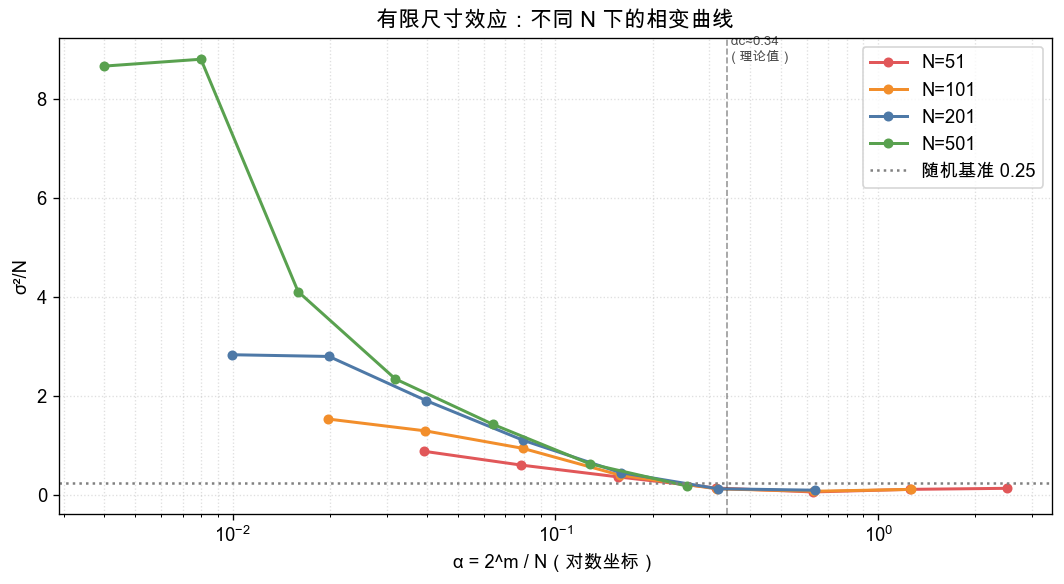

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e15759', '#f28e2b', '#4e79a7', '#59a14f']

for (N, res), color in zip(all_results.items(), colors):
    ax.plot(res[:, 0], res[:, 1], 'o-', color=color, linewidth=1.8,
            markersize=5, label=f'N={N}')

ax.axhline(0.25, color='gray', linestyle=':', linewidth=1.5, label='随机基准 0.25')
ax.set_xscale('log')
ax.set_xlabel('α = 2^m / N（对数坐标）')
ax.set_ylabel('σ²/N')
ax.set_title('有限尺寸效应：不同 N 下的相变曲线', fontweight='bold')
ax.legend()
ax.grid(True, which='both', linestyle=':', alpha=0.4)

# 标注理论临界点
ax.axvline(0.34, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax.text(0.34, ax.get_ylim()[1]*0.95, ' αc≈0.34\n（理论值）',
        fontsize=8, color='black', alpha=0.7)

plt.tight_layout()
plt.show()

## 策略数 s 的影响

当每个 agent 拥有更多策略（s 更大）时，他们能更快地适应变化。这会改善还是损害集体协调？

In [11]:
N = 201
s_values = [1, 2, 3, 5, 8]
m_values = range(1, 8)
T_sim = 1200
n_seeds = 6

print("正在运行 s 扫描...")
s_results = {}
for s in s_values:
    res = []
    for m in m_values:
        alpha = (2**m) / N
        sigma2_list = []
        for seed in range(n_seeds):
            mg = MinorityGame(N=N, m=m, s=s, seed=seed)
            mg.run(T_sim)
            A = np.array(mg.attendance_log[T_sim//2:])
            sigma2_list.append(A.var() / N)
        res.append((alpha, np.mean(sigma2_list)))
    s_results[s] = np.array(res)
    print(f'  s={s} 完成')
print("完成！")

正在运行 s 扫描...
  s=1 完成
  s=2 完成
  s=3 完成
  s=5 完成
  s=8 完成
完成！


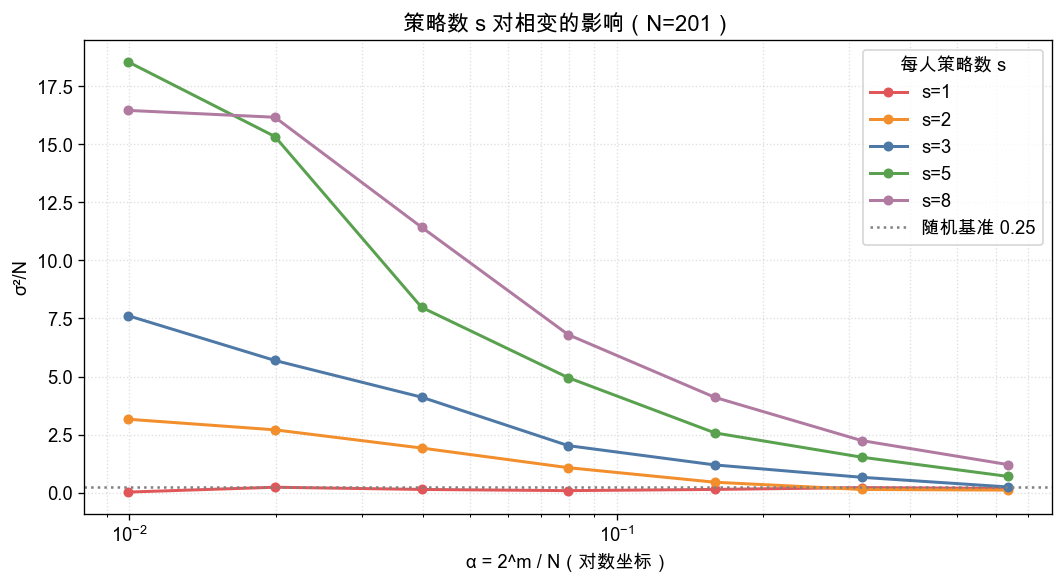

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e15759', '#f28e2b', '#4e79a7', '#59a14f', '#b07aa1']

for (s, res), color in zip(s_results.items(), colors):
    ax.plot(res[:, 0], res[:, 1], 'o-', color=color, linewidth=1.8,
            markersize=5, label=f's={s}')

ax.axhline(0.25, color='gray', linestyle=':', linewidth=1.5, label='随机基准 0.25')
ax.set_xscale('log')
ax.set_xlabel('α = 2^m / N（对数坐标）')
ax.set_ylabel('σ²/N')
ax.set_title(f'策略数 s 对相变的影响（N={N}）', fontweight='bold')
ax.legend(title='每人策略数 s')
ax.grid(True, which='both', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

## 小结：相变意味着什么？

### 物理学的类比

少数派博弈的相变与铁磁相变在数学结构上高度类似：

| 铁磁相变 | 少数派博弈 |
|---|---|
| 温度 T | α = 2ᵐ / N |
| 磁化强度 M | 出勤偏差 A - N/2 |
| 铁磁相（有序）| 拥挤相（羊群效应）|
| 顺磁相（无序）| 稀疏相（趋近随机）|
| 居里温度 Tc | 临界点 αc ≈ 0.34 |

这说明复杂系统中的涌现现象可能有**普适的数学结构**，跨越物理、生物、经济等不同领域。